# 前馈-反馈路径跟踪控制器 (F2004 @ Barcelona)

**纯论文前馈-反馈** (无 pure-pursuit 兜底)。横向 = 论文 2-DoF 前馈 + PD 反馈；纵向先用恒速模式，专注调横向。

- 参考线: `ks_barcelona_racing_line.csv` (`pos_x, pos_y, speed[m/s], lap_dist`)
- 状态字段 / 控制约定 / 符号 均对齐已验证的接口:
  - 纵向速度 `local_velocity_x`，横向速度 `local_velocity_y`，横摆角速度 `angular_velocity_y`
  - 进度 `NormalizedSplinePosition` × `TrackLength`，圈数 `LapCount`
  - acc/brake ∈ [-1,1] (-1=完全松开)；转向 `steer = STEER_SIGN·deg(δ)·RATIO/LOCK`

### 横向 (论文式 14/15/16)
$\delta_{FFW}=\dfrac{-U_x r - x_p a_{21}\beta - x_p a_{22} r + U_x\kappa\dot s + x_p(\kappa\dot s + \dot\kappa\dot s^2)}{x_p b_{21}}$,
$\quad\delta_{FB}=-K_2 e_p - K_3\Delta\Phi$, $\quad e_p = e + x_p\Delta\Phi$, $\quad\delta=\delta_{FFW}+\delta_{FB}$

## 1. 导入

In [25]:
%matplotlib inline
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.spatial import cKDTree
from omegaconf import OmegaConf

sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

import logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s', datefmt='%H:%M:%S')

## 2. 连接 AC

In [26]:
config = OmegaConf.load("config.yml")
client = assettoCorsa.make_client_only(config.AssettoCorsa)
static_info = client.simulation_management.get_static_info()
TRACK_LENGTH = float(static_info['TrackLength'])
print(f"Track: {static_info['TrackFullName']}, length = {TRACK_LENGTH:.1f} m")
client.setup_connection()
state = client.step_sim()
print(f"pos=({state['world_position_x']:.1f}, {state['world_position_y']:.1f}), "
      f"Ux={state['local_velocity_x']:.1f}")
print(f"NSP={state['NormalizedSplinePosition']:.4f}, "
      f"s={TRACK_LENGTH*state['NormalizedSplinePosition']:.1f}")

INFO:AssettoCorsaEnv.ac_client:AC Client. Listening at host: localhost port: 2345
INFO:AssettoCorsaEnv.ac_client:Client connected on 2345


Track: ks_nurburgring-layout_gp_a, length = 5077.9 m
pos=(-873.2, -179.1), Ux=0.0
NSP=0.9070, s=4605.7


## 3. 参考路径
读 `ks_barcelona_racing_line.csv`，重采样为等弧长点，用 spline 算航向/曲率/曲率变化率。
速度参考用 `speed` 列 (已是 m/s)。

In [27]:
rl_df = pd.read_csv('ks_nurburgring_racing_line.csv')
rl_df = rl_df.sort_values('lap_dist').drop_duplicates('lap_dist').reset_index(drop=True)

raw_xy = rl_df[['pos_x','pos_y']].values  
raw_v  = rl_df['speed'].values          # m/s
raw_s  = rl_df['lap_dist'].values       # 弧长 [m]

# 等弧长重采样 (用赛道长度 TRACK_LENGTH 做闭合)
N = int(TRACK_LENGTH)
rl_s = np.linspace(0, TRACK_LENGTH, N, endpoint=False)
rl_xy = np.column_stack([
    interp1d(raw_s, raw_xy[:,0], fill_value='extrapolate')(rl_s),
    interp1d(raw_s, raw_xy[:,1], fill_value='extrapolate')(rl_s)])
rl_v = np.maximum(
    gaussian_filter1d(interp1d(raw_s, raw_v, fill_value='extrapolate')(rl_s), sigma=5),
    5.0)

# spline 求导 -> 航向 / 曲率 / 曲率变化率
sx = UnivariateSpline(rl_s, rl_xy[:,0], k=4, s=0)
sy = UnivariateSpline(rl_s, rl_xy[:,1], k=4, s=0)
dx,  dy  = sx.derivative(1)(rl_s), sy.derivative(1)(rl_s)
ddx, ddy = sx.derivative(2)(rl_s), sy.derivative(2)(rl_s)
rl_yaw   = np.arctan2(dy, dx)
rl_kappa = gaussian_filter1d((dx*ddy - dy*ddx) / (dx**2 + dy**2)**1.5, sigma=8)
rl_dkds  = np.gradient(rl_kappa, rl_s)

rl_v = gaussian_filter1d(rl_v, sigma=2)
rl_v = np.maximum(rl_v, 5.0)

rl_tree  = cKDTree(rl_xy)

d_chk, _ = rl_tree.query([state['world_position_x'], state['world_position_y']])
print(f"对齐检查: 车到参考线最近距离 = {d_chk:.2f} m {'✓' if d_chk<10 else '✗ (坐标系可能不对)'}")
print(f"v_ref (AI原始): {rl_v.min():.1f}~{rl_v.max():.1f} m/s, {N} 点, "
      f"|kappa|max={np.abs(rl_kappa).max():.4f} (最小半径 {1/np.abs(rl_kappa).max():.1f} m)")


对齐检查: 车到参考线最近距离 = 1.68 m ✓
v_ref (AI原始): 21.0~85.6 m/s, 5077 点, |kappa|max=0.0400 (最小半径 25.0 m)


## 4. 参考线可视化 (静态检查)

C:\Users\14212\AppData\Local\Temp\ipykernel_27420\1776828034.py:7: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\1776828034.py:7: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\1776828034.py:7: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\1776828034.py:7: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\1776828034.py:7: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\1776828034.py:7: UserWarn

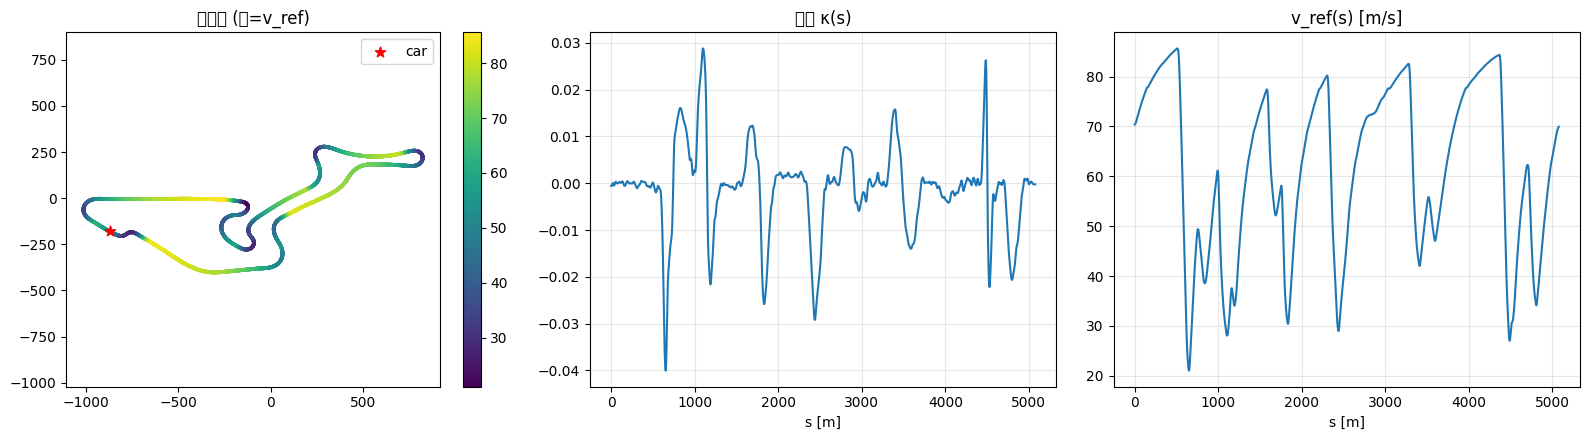

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
sc = axs[0].scatter(rl_xy[:,0], rl_xy[:,1], c=rl_v, s=3, cmap='viridis')
axs[0].scatter([state['world_position_x']],[state['world_position_y']], c='r', s=60, marker='*', label='car')
axs[0].set_title('参考线 (色=v_ref)'); axs[0].axis('equal'); axs[0].legend(); plt.colorbar(sc, ax=axs[0])
axs[1].plot(rl_s, rl_kappa); axs[1].set_title('曲率 κ(s)'); axs[1].set_xlabel('s [m]'); axs[1].grid(alpha=0.3)
axs[2].plot(rl_s, rl_v);     axs[2].set_title('v_ref(s) [m/s]'); axs[2].set_xlabel('s [m]'); axs[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. 车辆参数 (ks_ferrari_f2004)


In [29]:
m  = 605.0
L  = 3.050
lf = L * 0.448      # 1.366 m
lr = L * 0.552      # 1.684 m
Cf = 109300.0       # 前轴侧偏刚度 N/rad (2×54670)
Cr = 139100.0       # 后轴侧偏刚度 N/rad (2×69530)
Iz = 0.55 * m       # 332.75 kg·m^2

STEER_LOCK  = 180.0          # 方向盘锁止角 ±°
STEER_RATIO = 15.0           # 转向比
DELTA_MAX   = np.deg2rad(STEER_LOCK / STEER_RATIO)  # 前轮最大转角 ±12°
STEER_SIGN  = +1.0           # AC 转向方向 (论文原符号: delta>0 -> 物理右转, steer 也>0)

print(f"F2004: m={m}, lf={lf:.3f}, lr={lr:.3f}, Iz={Iz:.1f}, δ_max=±{np.degrees(DELTA_MAX):.1f}°")


F2004: m=605.0, lf=1.366, lr=1.684, Iz=332.8, δ_max=±12.0°


## 6. 横向控制器 — 纯论文前馈-反馈

系数符号已对齐实际坐标系/state 定义 (与论文式 9 等价，仅整体符号随坐标约定调整):
- $a_{21}=(l_r C_r - l_f C_f)/I_z$,  $a_{22}=-(l_f^2 C_f + l_r^2 C_r)/(I_z U_x)$,  $b_{21}=l_f C_f/I_z$

前馈含必要的幅度限制 (防止 yaw rate 暂态时前馈暴增)，但**不含 pure-pursuit 兜底**。低速 ($U_x<5$) 退化为运动学前馈 $\delta = L\kappa$。

In [30]:
# ===== 可调增益 (速度调度) =====
# 三段调度: 低速强反馈 -> 中速温和 -> 高速极保守 (防直道方向盘抖)
# 低速基准 (Ux=12 m/s): K2=0.10, K3=0.80 (已验证稳)
# 中速基准 (Ux=30 m/s): K2=0.05, K3=0.40
# 高速基准 (Ux=60 m/s): K2=0.02, K3=0.20 (高速抖动主因)
K2_LOW, K2_MID, K2_HIGH = 0.11, 0.050, 0.018  # 提速后稍微加强高速位置反馈
K3_LOW, K3_MID, K3_HIGH = 0.70, 0.32, 0.13   # 提速后稍微加强航向反馈
V_GAIN_REF_LOW  = 12.0
V_GAIN_REF_MID  = 20.0    # 拐点提前: 30->20 (30m/s高速失稳, 需更早进保守档)
V_GAIN_REF_HIGH = 35.0    # 拐点提前: 60->35 (~30m/s时增益接近HIGH保守值)
X_P = 0.5      # 论文中 x_p (前馈用, 不动)
# ===== 反馈用动态前视 (与FF的X_P解耦): x_la = t_preview·|Ux|, 提供相位超前=阻尼 =====
# 原 X_P=0.5m 在高速下几乎无超前 -> 航向欠阻尼振荡. 改成随速度前视.
X_LA_T   = 0.24    # 前视时间 [s] (典型 0.3~0.5)
X_LA_MIN = 2.0    # 前视下限 [m] (低速)
X_LA_MAX = 7.0   # 前视上限 [m] (高速封顶, 防过度超前)
KAPPA_SIGN_STEER = -1.0   # 模型前馈(期望值)需 -1: 与已跑通的几何前馈符号一致 (见验证)

# 切回论文模型前馈 (几何前馈仅用于验证符号)
USE_KINEMATIC_FF = False

# 前馈转角限幅，不再用原来的 *0.6 过度压小
A_LAT_FF_MAX = 45.0
A_LAT_MAX = 42.0  # 横向加速度上限 [m/s^2]
DFF_GAIN = 0.43
KIN_FF_GAIN = 0.82
def lat_gains(Ux):
    """三段速度调度."""
    v = abs(Ux)
    if v <= V_GAIN_REF_LOW:  return K2_LOW, K3_LOW
    if v >= V_GAIN_REF_HIGH: return K2_HIGH, K3_HIGH
    if v <= V_GAIN_REF_MID:
        f = (v - V_GAIN_REF_LOW) / (V_GAIN_REF_MID - V_GAIN_REF_LOW)
        return K2_LOW + f*(K2_MID - K2_LOW), K3_LOW + f*(K3_MID - K3_LOW)
    f = (v - V_GAIN_REF_MID) / (V_GAIN_REF_HIGH - V_GAIN_REF_MID)
    return K2_MID + f*(K2_HIGH - K2_MID), K3_MID + f*(K3_HIGH - K3_MID)

# ===== 安全参数 =====
V_GAIN_FULL = 12.0
V_GAIN_MIN  = 3.0
GAIN_FLOOR  = 0.15
DPHI_RUNAWAY = np.deg2rad(80.0)

# ===== FFB 公式各项的噪声硬限幅 =====
BETA_MAX = np.deg2rad(10.0)
R_MAX    = np.deg2rad(60.0)
DKDS_MAX = 0.005

# ===== 前馈输出低通 (dt 感知: alpha=dt/(tau+dt), 不再随循环节拍变) =====
# tau=0.12s 对应名义 dt=0.04s 时 alpha=0.25, 保持原行为但抗 dt 抖动
DFF_LPF_TAU = 0.12
_dff_state = {'dff': 0.0, 'init': False}
def reset_lpf():
    _dff_state['init'] = False   # 重置前馈滤波状态

def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def find_nearest(px, py, hint_s=None, prev_idx=None):
    if prev_idx is not None:
        # 窗口扩大到 ±120, 但距离阈值收紧到 10m 防匹配对面直道
        lo, hi = max(prev_idx-120, 0), min(prev_idx+120, N)
        d2 = (rl_xy[lo:hi,0]-px)**2 + (rl_xy[lo:hi,1]-py)**2
        best_local = lo + int(np.argmin(d2))
        if np.sqrt(d2.min()) < 10.0:   # 距离阈值收紧: 10m 内才信任局部匹配
            return best_local
    if hint_s is not None:
        c = int(hint_s % TRACK_LENGTH) % N
        lo, hi = max(c-60,0), min(c+60, N)
        d2 = (rl_xy[lo:hi,0]-px)**2 + (rl_xy[lo:hi,1]-py)**2
        if np.sqrt(d2.min()) < 30:
            return lo + int(np.argmin(d2))
    _, best = rl_tree.query([px, py])
    return int(best)

def compute_steer(state, idx, dt):
    """论文 2-DoF 前馈 + PD 反馈 (论文式 9/14/15/16, 原符号约定).
    
    论文式 (9) 原符号:
        a21 =  (lf*Cf - lr*Cr) / Iz
        a22 =  (lf²*Cf + lr²*Cr) / (Iz*Ux)
        b21 = -lf*Cf / Iz
    
    论文约定 delta>0 -> 前轮(物理)右转, 配合 STEER_SIGN=+1.
    """
    px  = state['world_position_x']
    py  = state['world_position_y']
    yaw = state['yaw']
    Ux  = state['local_velocity_x']
    Uy  = state['local_velocity_y']
    r   = state['angular_velocity_y']

    # ---- 误差 ----
    dx_r, dy_r = px - rl_xy[idx,0], py - rl_xy[idx,1]
    phi_p = rl_yaw[idx]
    e     = -np.sin(phi_p)*dx_r + np.cos(phi_p)*dy_r
    dphi  = wrap_pi(yaw - phi_p)
    kappa_raw = rl_kappa[idx]
    dkds_raw  = float(np.clip(rl_dkds[idx], -DKDS_MAX, DKDS_MAX))

    # 转成控制器符号: delta > 0 = 右转
    kappa = KAPPA_SIGN_STEER * kappa_raw
    dkds  = KAPPA_SIGN_STEER * dkds_raw

    # ---- 速度相关的反馈增益衰减 ----
    v = abs(Ux)
    if v >= V_GAIN_FULL: gain_scale = 1.0
    elif v <= V_GAIN_MIN: gain_scale = GAIN_FLOOR
    else: gain_scale = GAIN_FLOOR + (1.0 - GAIN_FLOOR)*(v - V_GAIN_MIN)/(V_GAIN_FULL - V_GAIN_MIN)

    # ===== 论文 model-based 前馈 (式14, 用论文式9原符号) =====
    Ux_c = max(abs(Ux), 3.0)
    a21 =  (lf*Cf - lr*Cr) / Iz                       # 论文原符号
    a22 =  (lf**2*Cf + lr**2*Cr) / (Iz * Ux_c)        # 论文原符号
    b21 = -lf*Cf / Iz                                  # 论文原符号

    # β 计算 + 硬限幅 (直通, 无低通)
    beta_raw = np.arctan2(Uy, max(abs(Ux), 0.5)) * (1.0 if Ux >= 0 else -1.0)
    beta   = float(np.clip(beta_raw, -BETA_MAX, BETA_MAX))
    r_safe = float(np.clip(r, -R_MAX, R_MAX))

    sd   = max(Ux_c, 0.5)
    ks   = kappa * sd
    kds_term = dkds * sd * sd

    # ===== 低速 β/r 淡入: 发车时 β=atan2(Uy,Ux) 在低 Ux 下发散, 实测项会踢方向盘
    # w=0 (Ux<6): 用曲率推出的稳态期望量 -> 平滑无踢动
    # w=1 (Ux>14): 用实测量 -> 恢复原有横摆阻尼
    # 连续混合, 同时消除原 Ux>5 硬分支的跳变 =====
    W_FADE_LO, W_FADE_HI = 6.0, 14.0
    w_meas = float(np.clip((abs(Ux) - W_FADE_LO) / (W_FADE_HI - W_FADE_LO), 0.0, 1.0))

    r_des = float(np.clip(kappa * Ux_c, -R_MAX, R_MAX))

    if USE_KINEMATIC_FF:
        dff = np.arctan(L * kappa)
    else:
        beta_des = float(np.clip(
            (lr - lf * m * Ux_c**2 / (Cr * L)) * kappa,
            -BETA_MAX, BETA_MAX
        ))

        # 前馈全部用期望(稳态)值, 不再混入实测 r/beta:
        #   r_des, beta_des 都由曲率 kappa 推出, 是 kappa 的光滑函数
        #   航向阻尼现在由反馈的动态前视 x_la 提供, FF 不再依赖实测 r
        beta_eff = beta_des
        r_eff    = r_des

        denom = X_P * b21
        num = (-Ux_c * r_eff
               - X_P * a21 * beta_eff
               - X_P * a22 * r_eff
               + Ux_c * ks
               + X_P * (ks + kds_term))

        dff_model = (num / denom) * DFF_GAIN
        dff_kin = KIN_FF_GAIN * np.arctan(L * kappa)

        # 大曲率连续弯里，模型前馈偏弱；用几何前馈逐渐接管
        ff_blend = float(np.clip((abs(kappa) - 0.012) / 0.018, 0.0, 1.0))
        dff = (1.0 - ff_blend) * dff_model + ff_blend * dff_kin

    # 保持现在这个限幅，不要回到旧的 *0.6
    dff_max = min(A_LAT_FF_MAX * L / Ux_c**2, DELTA_MAX)
    dff = float(np.clip(dff, -dff_max, dff_max))

    # 前馈输出低通 (dt 感知)
    if not _dff_state['init']:
        _dff_state['dff'] = dff; _dff_state['init'] = True
    alpha = dt / (DFF_LPF_TAU + dt)
    _dff_state['dff'] = alpha * dff + (1.0 - alpha) * _dff_state['dff']
    dff = _dff_state['dff']
    # 大误差/大航向角时，前馈不再主导，先救回车身姿态
    large_err = (abs(e) > 3.5) or (abs(dphi) > np.deg2rad(12.0))

    ff_fade_e = float(np.clip((abs(e) - 3.0) / 2.0, 0.0, 1.0))
    ff_fade_phi = float(np.clip((abs(dphi) - np.deg2rad(10.0)) / np.deg2rad(10.0), 0.0, 1.0))
    ff_fade = max(ff_fade_e, ff_fade_phi)

    dff *= (1.0 - ff_fade)

    # ===== PD 反馈 (式15, 论文原文是 -K2*e_p - K3*dphi) =====
    # 论文约定: e>0 = 车在路径左侧 -> 应该右转(delta>0) -> 反馈 +K2*e
    # 论文式15 写 -K2*e_p, 但论文里 e_p 的符号约定是反的 (e>0 = 车在路径右侧)
    # 我们这版 e>0 = 车在路径左侧, 所以反馈应该是 +K2*e + K3*dphi
    K2_v, K3_v = lat_gains(Ux)
    # 高速死区: 直道上极小误差不响应, 消除方向盘微抖 (低速不设死区保证跟踪)
    if abs(Ux) > 40.0:
        e_db    = e    if abs(e)    > 0.08 else 0.0      # |e|<8cm 死区
        dphi_db = dphi if abs(dphi) > np.deg2rad(0.4) else 0.0  # |dphi|<0.4° 死区
    else:
        e_db, dphi_db = e, dphi
    # 动态前视: 看前方 x_la 米处的误差, 提前修航向 (核心阻尼来源)
    x_la = float(np.clip(X_LA_T * abs(Ux), X_LA_MIN, X_LA_MAX))
    preview_cap = 2.0 if large_err else 1.0
    dphi_preview = float(np.clip(x_la * dphi_db, -preview_cap, preview_cap))
    e_p = e_db + dphi_preview

    e_fb_term = K2_v * e_p
    dphi_fb_term = K3_v * dphi_db

    if large_err:
        E_FB_LIMIT = np.deg2rad(3.0)
        DPHI_FB_LIMIT = np.deg2rad(7.0)
    else:
        E_FB_LIMIT = np.deg2rad(4.0)
        DPHI_FB_LIMIT = np.deg2rad(4.0)

    e_fb_term = float(np.clip(e_fb_term, -E_FB_LIMIT, E_FB_LIMIT))
    dphi_fb_term = float(np.clip(dphi_fb_term, -DPHI_FB_LIMIT, DPHI_FB_LIMIT))

    dfb = (e_fb_term + dphi_fb_term) * gain_scale

    # ===== 失稳保护 =====
    runaway = abs(dphi) > DPHI_RUNAWAY
    if runaway:
        dff = 0.0
        # dphi>0 (车头偏左) -> 应右转 (delta>0) -> +sign(dphi)*...
        dfb = float(np.sign(dphi) * DELTA_MAX * 0.4)

    # ===== 总前轮转角 (式16) =====
    delta = dff + dfb
    Ux_safe = max(abs(Ux), 5.0)
    # 转角限幅: 用横向加速度上限算, 但加绝对下限5°保证高速也能修正航向
    # (否则高速时 A_LAT_MAX/Ux² 把转角限到~2°, 航向发散时扳不回来僵死)
    delta_max = min(max(A_LAT_MAX * L / Ux_safe**2, np.deg2rad(5.0)), DELTA_MAX)
    delta = float(np.clip(delta, -delta_max, delta_max))

    steer = STEER_SIGN * np.rad2deg(delta) * STEER_RATIO / STEER_LOCK
    steer = float(np.clip(steer, -1, 1))

    return steer, dict(e=e, dphi=dphi, delta=delta, dff=dff, dfb=dfb,
                       steer=steer, kappa=kappa, beta=beta, r=r_safe,
                       r_des=r_des,
                       w_meas=w_meas, x_la=x_la, gain_scale=gain_scale, runaway=int(runaway))


## 7. 主循环

`acc/brake ∈ [-1,1]`，归一化油门 u∈[0,1] 映射为 `acc=2u-1, brake=-1`；刹车同理。
中断 (`Ctrl-C`) 或跑满 `MAX_LAPS` 圈后安全停车。

In [31]:
MAX_LAPS    = 2
LOG_EVERY   = 25

# ===== 纵向控制器参数 =====
VLON_LOOKAHEAD_K   = 2.0     # 动态前视: look_dist = K*Ux
VLON_LOOKAHEAD_MIN = 5.0
VLON_LOOKAHEAD_MAX = 200.0    # 缩短纵向预瞄, 减少直道被远处慢弯提前拉慢
VLON_USE_MIN_INWIN = True    # 取窗口内最小速度 (提前准备减速)
DECEL_RATE_MAX     = 90.0    # v_ref 单步最大减少率 [m/s/s]
ACCEL_RATE_VREF_MAX = 16.0
_GRIP_V_RUN      = np.array([8, 20, 30, 40, 50, 60, 78, 100])
_GRIP_A_RUN      = np.array([12, 25, 31, 38, 40, 43, 44, 44])
GRIP_SCALE_RUN   = 0.95
PID_KP           = 1.45
PID_KI           = 0.35
PID_KD           = 0.08
PID_I_LIMIT      = 5.0
A_MAX_DRIVE      = 15.0
A_MAX_BRAKE      = 35.0
A_LAT_VREF_MAX   = 44.0   # 曲率限速只做安全顶, 不再砍弯速到参考曲线以下
PEDAL_DRV_REF    = 16.0   # (保留, 已不直接用)
# 驱动踏板参考加速度 vs 速度 (满油可达加速度, 功率/阻力限): 高速更小 -> 同 a_cmd 踩更多油
# 解决直道追不上 AI 速度: 原 16 与速度无关, 高速严重高估可达加速度
_PEDAL_DRV_V   = np.array([0.0, 25.0, 40.0, 55.0, 70.0, 85.0])
_PEDAL_DRV_REF = np.array([17.0, 16.0, 11.0,  6.2,  3.8,  3.0])
PEDAL_BRK_REF    = 6.8
BRAKE_PLAN       = 7.0
RAMP_STEPS      = 90
VREF_SCALE      = 0.92   # 第一档提速: 稳定后再逐步加到 0.94/0.96
VREF_E_DEAD     = 1.1
VREF_E_FULL     = 3.0
VREF_E_MIN_FAC  = 0.65
PANIC_E         = 4.0
PANIC_DPHI      = np.deg2rad(14.0)
STEER_RATE_PER_S = 1.0   # 提速后提高名义转向速率上限
WARMUP_SPEED    = 8.0
WARMUP_STEER_LIMIT = 0.05
# ===== 发车直线硬限角 (防 转向×满油 引发的功率过度转向甩尾) =====
V_LAUNCH_HOLD   = 12.0    # 此速度以下: 方向盘硬限在 LAUNCH_STEER_CAP
V_LAUNCH_FULL   = 18.0    # 此速度以上: 全权限; 之间线性放开
LAUNCH_STEER_CAP = 0.25   # 归一化 (~1.5° 前轮): 够修直线小漂移, 不足以激发后轴失抓

dbg = {
    'verbose_every': 25,
    'print_once':    False,
    'pause':         False,
}

# ===== 状态变量 =====
history = []; start_lap = None; prev_idx = None
prev_steer = 0.0
v_err_int  = 0.0
prev_v_err = 0.0
prev_v_ref = 0.0
last_s     = None

client.reset()
reset_lpf()  # 清前馈低通残留
time.sleep(0.05)
logger.info("起步: 已复位")

t_prev = time.perf_counter(); step = 0

try:
    while True:
        state = client.step_sim()
        if state.get('done'):
            logger.info('done=True'); break
        t_now = time.perf_counter(); dt = max(t_now - t_prev, 1e-3); t_prev = t_now
        px, py = state['world_position_x'], state['world_position_y']
        Ux  = state['local_velocity_x']
        s_ref = TRACK_LENGTH * state['NormalizedSplinePosition']
        lap = state.get('LapCount', 0)
        if start_lap is None: start_lap = lap

        # ---- 路径点匹配 ----
        idx_new = find_nearest(px, py, hint_s=s_ref, prev_idx=prev_idx)
        if prev_idx is not None:
            jump = abs(idx_new - prev_idx)
            jump = min(jump, N - jump)
            if jump > 200:
                d2_all = (rl_xy[:,0]-px)**2 + (rl_xy[:,1]-py)**2
                mask = np.zeros(N, dtype=bool)
                lo_g = (prev_idx - 400) % N
                hi_g = (prev_idx + 400) % N
                if lo_g < hi_g: mask[lo_g:hi_g] = True
                else:           mask[lo_g:] = True; mask[:hi_g] = True
                idx_new = int(np.argmin(np.where(mask, d2_all, np.inf)))
        idx = idx_new
        prev_idx = idx

        # ---- 横向控制 (论文 FFB) ----
        steer, ff_info = compute_steer(state, idx, dt)
        e_now    = ff_info['e']
        dphi_now = ff_info['dphi']
        delta    = ff_info['delta']
        delta_ff = ff_info['dff']
        delta_fb = ff_info['dfb']
        beta_m   = ff_info['beta']
        r_m      = ff_info['r']
        gscale   = ff_info['gain_scale']

        # 发车直线硬限角: 直道起步先走直线, 不让转向激发后轴失抓; 12->18 m/s 放开
        av = abs(Ux)
        if step < RAMP_STEPS and av < V_LAUNCH_HOLD:
            steer_lim = LAUNCH_STEER_CAP
        elif step < RAMP_STEPS and av < V_LAUNCH_FULL:
            steer_lim = LAUNCH_STEER_CAP + (1.0 - LAUNCH_STEER_CAP) * (av - V_LAUNCH_HOLD) / (V_LAUNCH_FULL - V_LAUNCH_HOLD)
        else:
            steer_lim = 1.0
        steer = float(np.clip(steer, -steer_lim, steer_lim))

        # 转向率限制 (dt 感知: 每秒上限 × dt)
        # 低速/弯中/大偏差时放开转向速率, 让方向跟得上
        kappa_now = abs(rl_kappa[idx])   # 提前到此处定义 (原在纵向段才算)
        if abs(e_now) > 2.5 or abs(dphi_now) > np.deg2rad(14.0):
            steer_rate = 1.8
        elif abs(Ux) < 30.0 or abs(kappa_now) > 0.012 or abs(e_now) > 0.8:
            steer_rate = 1.2
        else:
            steer_rate = STEER_RATE_PER_S
        if prev_steer * steer < -0.02:
            steer_rate = max(steer_rate, 2.8)
        d_steer_max = steer_rate * dt
        d_steer = np.clip(steer - prev_steer, -d_steer_max, d_steer_max)
        steer = float(np.clip(prev_steer + d_steer, -1, 1))
        prev_steer = steer

        # ---- 纵向控制 ----
        ds_ref = TRACK_LENGTH / N

        look_dist = float(np.clip(
            VLON_LOOKAHEAD_K * abs(Ux),
            VLON_LOOKAHEAD_MIN,
            VLON_LOOKAHEAD_MAX
        ))
        lookahead_pts = int(look_dist / ds_ref) + 1

        win_offsets = np.arange(0, lookahead_pts + 1)
        win_idxs = (idx + win_offsets) % N
        win_v = rl_v[win_idxs]

        # 不再直接取窗口最小值；改成“按刹车距离允许的最高速度”
        j_min = int(np.argmin(win_v))
        v_min = float(win_v[j_min])
        dist_to_min = float(win_offsets[j_min] * ds_ref)

        v_brake = np.sqrt(v_min**2 + 2.0 * BRAKE_PLAN * max(dist_to_min - 5.0, 0.0))
        v_target_path = min(float(rl_v[idx]), float(v_brake))

        v_ref_raw = v_target_path * VREF_SCALE

        # 曲率限速只做最后安全顶，不作为主要速度曲线
        curve_look_dist = float(np.clip(0.7 * abs(Ux), 25.0, 80.0))
        curve_pts = int(curve_look_dist / ds_ref) + 1
        curve_idxs = (idx + np.arange(curve_pts + 1)) % N
        k_abs_max = float(np.max(np.abs(rl_kappa[curve_idxs])))

        if k_abs_max > 1e-4:
            v_curve = np.sqrt(A_LAT_VREF_MAX / k_abs_max)
            v_ref_raw = min(v_ref_raw, v_curve)
        
        # server reset 检测
        if last_s is not None and abs(s_ref - last_s) > 100 and abs(Ux) < 1.0:
            logger.warning(f'[step {step}] 检测到 reset, 重置控制器状态')
            v_err_int = 0.0; prev_steer = 0.0; prev_v_ref = 0.0
            reset_lpf()
        last_s = s_ref

        # 起步爬速
        if step < RAMP_STEPS:
            v_cap = max(v_ref_raw * (step / RAMP_STEPS), 4.0)
            v_ref = float(min(v_ref_raw, v_cap))
        else:
            v_ref = v_ref_raw

        # 横向偏差减速
        ae = abs(e_now)
        if ae <= VREF_E_DEAD:   e_factor = 1.0
        elif ae >= VREF_E_FULL: e_factor = VREF_E_MIN_FAC
        else:
            f = (ae - VREF_E_DEAD) / (VREF_E_FULL - VREF_E_DEAD)
            e_factor = 1.0 - f * (1.0 - VREF_E_MIN_FAC)
        v_ref *= e_factor

        # panic 减速
        if (abs(e_now) > PANIC_E) or (abs(dphi_now) > PANIC_DPHI):
            v_ref = min(v_ref, max(max(Ux, 0) * 0.5, 3.0))

        # v_ref 减速率限制
        if prev_v_ref > 0.1:
            v_ref = float(np.clip(
                v_ref,
                prev_v_ref - DECEL_RATE_MAX * dt,
                prev_v_ref + ACCEL_RATE_VREF_MAX * dt
            ))
        prev_v_ref = v_ref

        # 纯 PID 纵向
        v_err  = float(np.clip(v_ref - Ux, -30.0, 30.0))
        d_err  = float(np.clip((v_err - prev_v_err) / dt, -50.0, 50.0))
        prev_v_err = v_err
        if Ux > -0.5:
            v_err_int = float(np.clip(v_err_int + v_err*dt, -PID_I_LIMIT, PID_I_LIMIT))
        a_cmd_raw = PID_KP*v_err + PID_KI*v_err_int + PID_KD*d_err

        # 起步/未对正软化
        if a_cmd_raw > 0:
            cap = A_MAX_DRIVE
            if abs(Ux) < 12.0:
                cap = min(cap, 6.0 + (A_MAX_DRIVE - 6.0) * (abs(Ux) / 12.0))
            if abs(e_now) > 3.0 or abs(dphi_now) > np.deg2rad(15.0):
                cap = min(cap, 4.0)
            elif abs(e_now) > 2.0 or abs(dphi_now) > np.deg2rad(8.0):
                cap = min(cap, 8.0)
            a_cmd_raw = min(a_cmd_raw, cap)

        # 卡姆圆刹车限幅
        a_total_now = float(np.interp(abs(Ux), _GRIP_V_RUN, _GRIP_A_RUN)) * GRIP_SCALE_RUN
        kappa_now   = abs(rl_kappa[idx])
        a_lat_now   = Ux*Ux*kappa_now
        if a_lat_now >= a_total_now:
            brake_avail = 3.0
        else:
            brake_avail = float(np.sqrt(a_total_now**2 - a_lat_now**2))
            brake_avail = min(brake_avail, 28.0)
            brake_avail = max(brake_avail, 3.0)
        a_cmd = float(np.clip(a_cmd_raw, -brake_avail, A_MAX_DRIVE))

        if a_cmd >= 0:
            pedal_ref = float(np.interp(abs(Ux), _PEDAL_DRV_V, _PEDAL_DRV_REF))
            u = float(np.clip(a_cmd / pedal_ref, 0.0, 1.0))

            # 出弯追不上 v_ref 时更积极给油，但只在车身基本稳定时启用
            boost_ready = (
                step > RAMP_STEPS + 30
                and abs(Ux) > 25.0
                and abs(e_now) < 0.8
                and abs(dphi_now) < np.deg2rad(4.0)
                and abs(kappa_now) < 0.010
            )

            if boost_ready and v_err > 5.0:
                u = max(u, 0.90)
            elif boost_ready and v_err > 3.5:
                u = max(u, 0.75)

            acc, brake = 2*u - 1, -1.0
        else:
            u = float(np.clip(-a_cmd / PEDAL_BRK_REF, 0.0, 1.0))
            acc, brake = -1.0, 2*u - 1

        client.controls.set_controls(steer=steer, acc=acc, brake=brake)
        client.respond_to_server()

        history.append(dict(t=t_now, step=step, s=s_ref, lap=lap,
            x=px, y=py, Ux=Ux, v_ref=v_ref, v_err=v_err,
            a_cmd=a_cmd, acc=acc, brake=brake,
            e=e_now, dphi=dphi_now, delta=delta, steer=steer,
            delta_ff=delta_ff, delta_fb=delta_fb,
            beta=beta_m, r=r_m, r_des=ff_info['r_des'], w_meas=ff_info['w_meas'],
            x_la=ff_info['x_la'], gain_scale=gscale, dt=dt,
            kappa=ff_info['kappa'], kappa_abs=kappa_now))

        should_print = (step % dbg['verbose_every'] == 0) or dbg['print_once']
        if should_print:
            tag = '*' if dbg['print_once'] else ' '
            logger.info(f"{tag}{step:5d} lap{lap} s={s_ref:6.1f} "
                        f"Ux={Ux:5.1f}/{v_ref:5.1f} "
                        f"e={e_now:+.2f} dΦ={np.degrees(dphi_now):+6.1f}° "
                        f"δ={np.degrees(delta):+5.1f}° steer={steer:+.3f} "
                        f"a_cmd={a_cmd:+5.1f}")
            dbg['print_once'] = False
        step += 1
        if lap - start_lap >= MAX_LAPS:
            logger.info(f'完成 {MAX_LAPS} 圈'); break

except KeyboardInterrupt:
    logger.info('用户中断')
finally:
    client.controls.set_controls(steer=0, acc=-1, brake=-1)
    client.respond_to_server()
    print(f'\n共 {len(history)} 步')


INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_client:AC Client. Listening at host: localhost port: 2345
INFO:AssettoCorsaEnv.ac_client:Client connected on 2345
INFO:__main__:起步: 已复位
INFO:__main__:     0 lap0 s=4576.0 Ux= -0.0/  4.0 e=-0.00 dΦ=  +1.0° δ= +0.3° steer=+0.002 a_cmd= +6.0
INFO:__main__:    25 lap0 s=4576.0 Ux=  0.9/ 10.9 e=-0.00 dΦ=  +1.0° δ= +0.3° steer=+0.026 a_cmd= +6.7
INFO:__main__:    50 lap0 s=4582.4 Ux= 11.9/ 22.7 e=-0.02 dΦ=  +0.2° δ= +0.3° steer=+0.027 a_cmd=+14.9
INFO:__main__:    75 lap0 s=4599.7 Ux= 22.9/ 37.0 e=+0.05 dΦ=  -2.0° δ= -0.6° steer=-0.051 a_cmd=+15.0
INFO:__main__:   100 lap0 s=4628.7 Ux= 35.3/ 49.5 e=-0.05 dΦ=  +0.1° δ= +0.1° steer=+0.008 a_cmd=+15.0
INFO:__main__:   125 lap0 s=4670.7 Ux= 47.6/ 50.0 e=-0.02 dΦ=  -0.3° δ= +0.0° steer=+0.000 a_cmd= +3.8
INFO:__main__:   150 lap0 s=4717.4 Ux= 44.7/ 44.7 e=-0.11 dΦ=  +0.3° δ= -0.0° steer=-0.002 a_cmd= +1.9
INFO:__main__:   175 lap0 s=4759.6 Ux= 39.


共 5693 步


## 实时调试 / 打印

主循环跑起来后, 在下面任何 cell 改 `dbg` 字典的值, **立即生效**(下一帧):

- `dbg['verbose_every'] = 1` -> 每帧都打印
- `dbg['verbose_every'] = 200` -> 减少打印频率
- `dbg['print_once'] = True` -> 下一帧立刻打印一次状态 (然后自动关回 False)

在 Jupyter 里另开一个 cell 跑下面这行即可.

In [32]:
# 用法示例 (在主循环跑的过程中, 另开 cell 跑这一行):
# dbg['print_once'] = True            # 立刻打印一次当前状态
# dbg['verbose_every'] = 5             # 改成高频打印
# dbg['verbose_every'] = 200           # 改成低频
dbg   # 查看当前调试设置

{'verbose_every': 25, 'print_once': False, 'pause': False}

## 8. 分析

In [33]:
df = pd.DataFrame(history)
df.to_csv('tracking_log.csv', index=False)
print(f'日志已存 tracking_log.csv ({len(df)} 行)')
if len(df) > 0:
    print(f"RMS e    = {np.sqrt((df.e**2).mean()):.3f} m")
    print(f"RMS dphi = {np.degrees(np.sqrt((df.dphi**2).mean())):.2f}°")
    print(f"max |e|  = {df.e.abs().max():.2f} m")

日志已存 tracking_log.csv (5693 行)
RMS e    = 0.376 m
RMS dphi = 1.58°
max |e|  = 3.92 m


C:\Users\14212\AppData\Local\Temp\ipykernel_27420\902901495.py:6: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\902901495.py:6: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\902901495.py:6: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\902901495.py:6: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\902901495.py:6: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\902901495.py:6: UserWarning: G

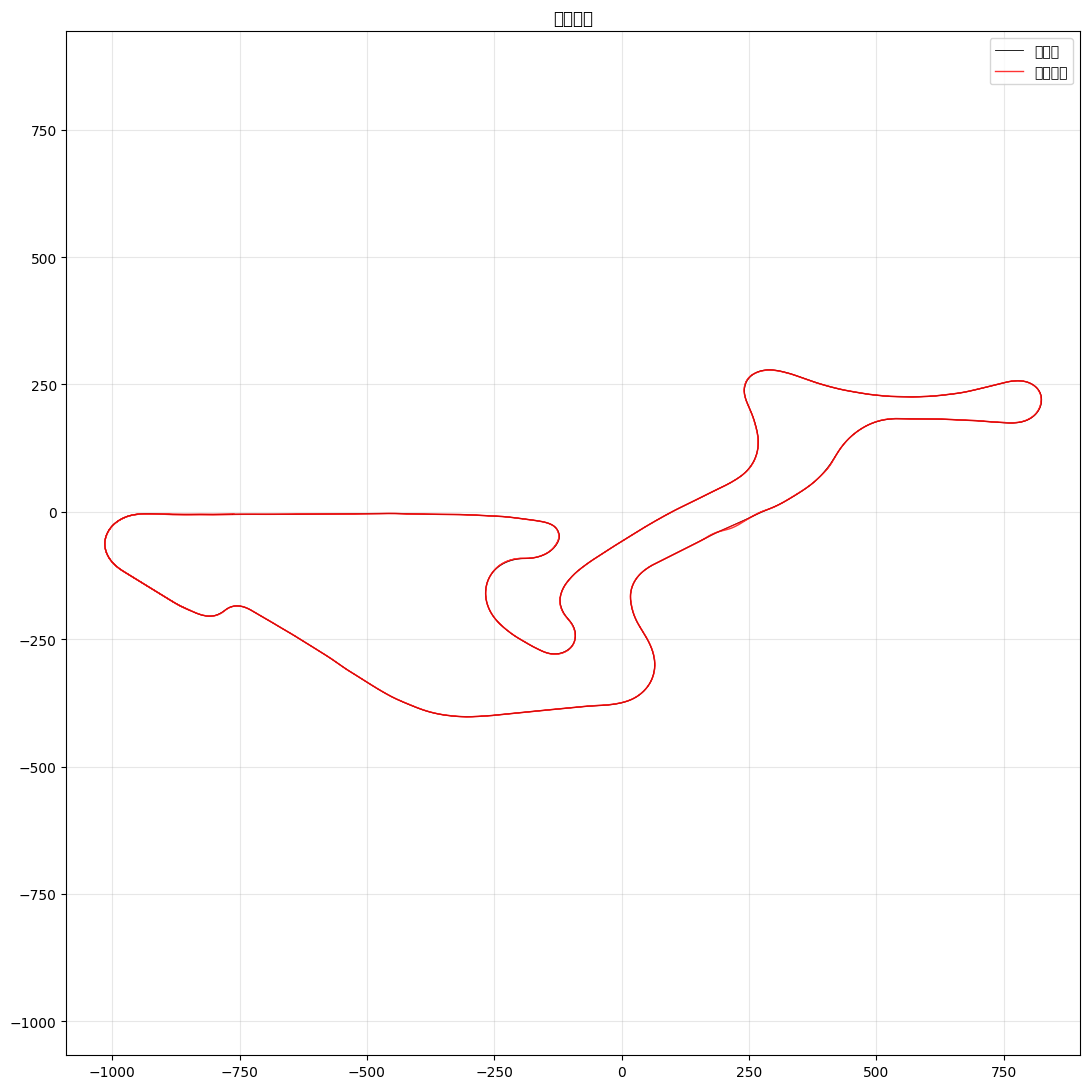

In [34]:
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.plot(rl_xy[:,0], rl_xy[:,1], 'k-', lw=0.6, label='参考线')
    ax.plot(df.x, df.y, 'r-', lw=1.0, alpha=0.8, label='实际轨迹')
    ax.axis('equal'); ax.legend(); ax.set_title('轨迹对比'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

C:\Users\14212\AppData\Local\Temp\ipykernel_27420\3461185506.py:42: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\3461185506.py:42: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\3461185506.py:42: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\3461185506.py:42: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\3461185506.py:42: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from current font.
  plt.tight_layout(); plt.show()
C:\Users\14212\AppData\Local\Temp\ipykernel_27420\3461185506.py:42: Us

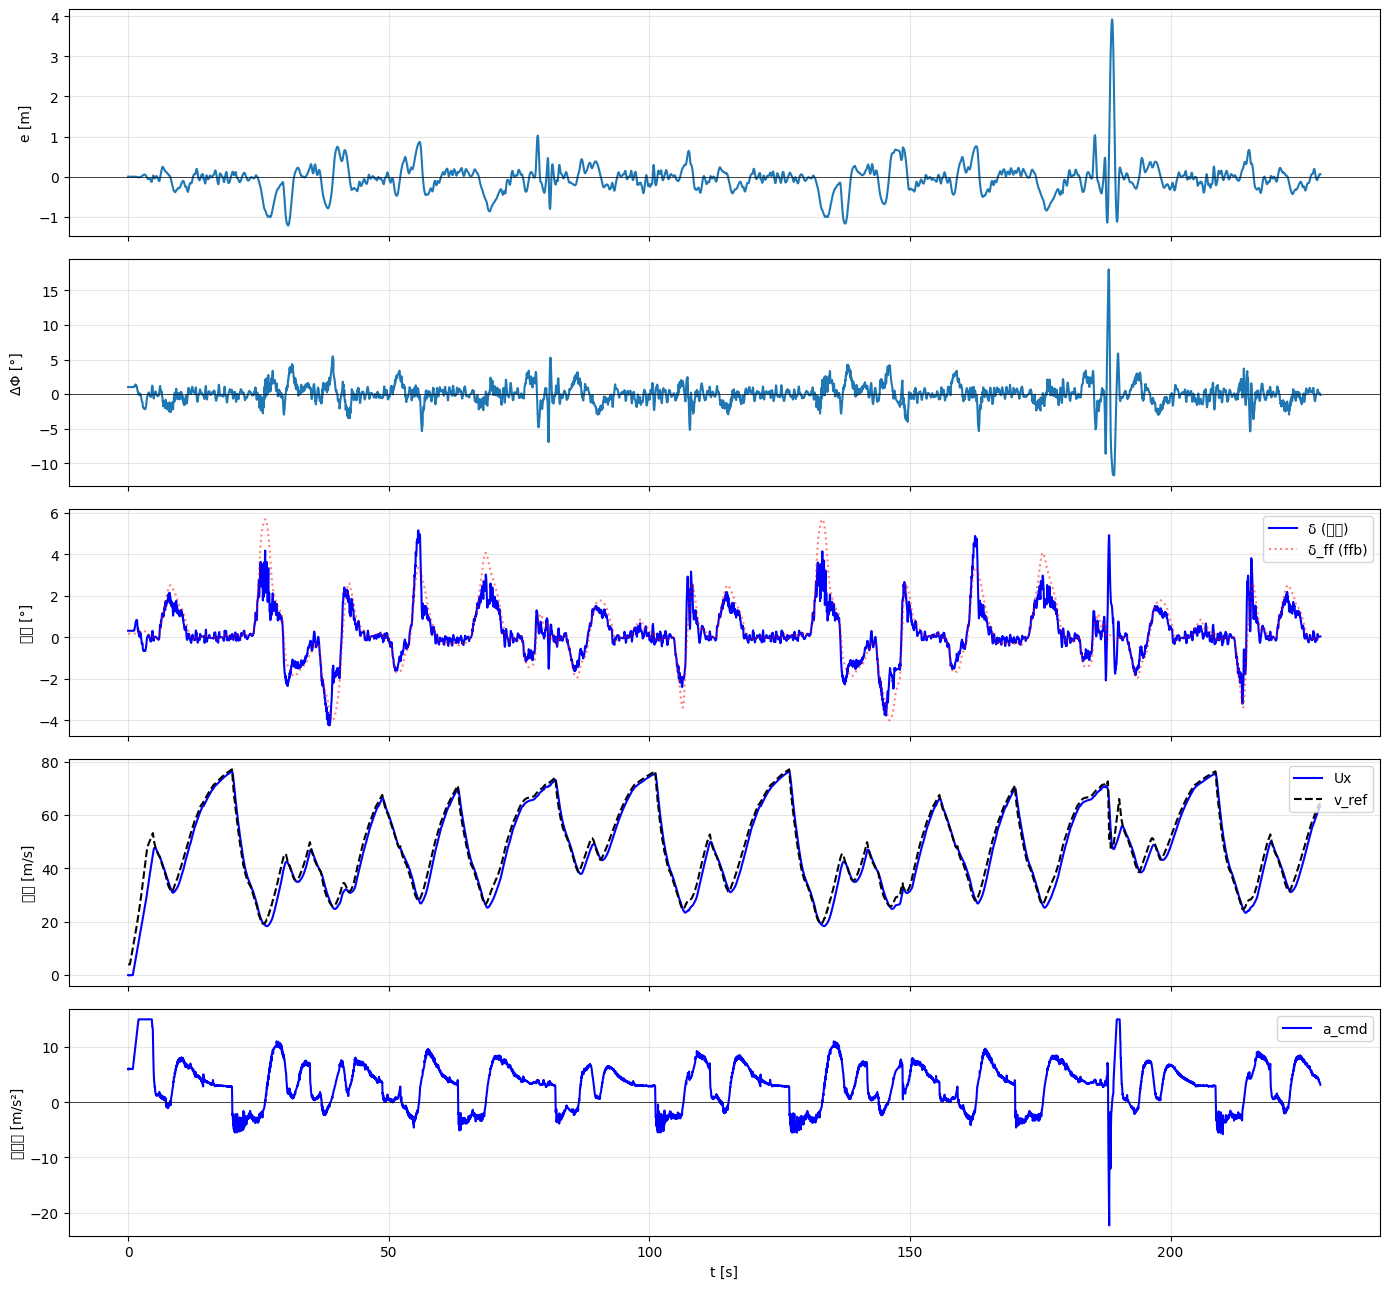

In [35]:
if len(df) > 0:
    fig, axs = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
    t0 = df['t'].iloc[0]; tt = df['t'] - t0
    
    # 横向偏差
    axs[0].plot(tt, df.e); axs[0].set_ylabel('e [m]')
    axs[0].axhline(0, color='k', lw=0.5); axs[0].grid(alpha=0.3)
    
    # 航向偏差
    axs[1].plot(tt, np.degrees(df.dphi)); axs[1].set_ylabel('ΔΦ [°]')
    axs[1].axhline(0, color='k', lw=0.5); axs[1].grid(alpha=0.3)
    
    # 转角: 实际 δ, 与 pursuit/ffb 两个候选
    axs[2].plot(tt, np.degrees(df.delta), label='δ (实际)', color='b')
    if 'delta_pp' in df.columns:
        axs[2].plot(tt, np.degrees(df.delta_pp), '--', alpha=0.5, label='δ_pp (pursuit)', color='g')
    if 'delta_ff' in df.columns:
        axs[2].plot(tt, np.degrees(df.delta_ff), ':', alpha=0.5, label='δ_ff (ffb)', color='r')
    axs[2].set_ylabel('转角 [°]'); axs[2].legend(loc='upper right'); axs[2].grid(alpha=0.3)
    
    # 速度跟踪
    axs[3].plot(tt, df.Ux, label='Ux', color='b')
    axs[3].plot(tt, df.v_ref, 'k--', label='v_ref')
    axs[3].set_ylabel('速度 [m/s]'); axs[3].legend(loc='upper right'); axs[3].grid(alpha=0.3)
    
    # 纵向加速度指令 + 油门/刹车
    if 'a_cmd' in df.columns:
        ax3b = axs[4]
        ax3b.plot(tt, df.a_cmd, label='a_cmd', color='b')
        if 'a_ff' in df.columns:
            ax3b.plot(tt, df.a_ff, '--', alpha=0.5, label='a_ff', color='g')
        if 'a_fb' in df.columns:
            ax3b.plot(tt, df.a_fb, ':', alpha=0.5, label='a_fb', color='r')
        ax3b.axhline(0, color='k', lw=0.5)
        ax3b.set_ylabel('加速度 [m/s²]'); ax3b.legend(loc='upper right'); ax3b.grid(alpha=0.3)
    else:
        axs[4].plot(tt, df.acc, label='acc', color='g')
        axs[4].plot(tt, df.brake, label='brake', color='r')
        axs[4].set_ylabel('油门/刹车'); axs[4].legend(loc='upper right'); axs[4].grid(alpha=0.3)
    
    axs[-1].set_xlabel('t [s]')
    plt.tight_layout(); plt.show()


In [36]:
client.close(); print('closed')

closed


## 调参提示

- **横向调参顺序**: 先 `K2=K3=0` 只看前馈能否跟弯；再加 `K3`(航向阻尼)；最后加 `K2`(纠正横向偏差)。
- **X_P** (投影距离): 增大→前视更远更平滑；减小→跟踪更紧但易抖。
- **STEER_SIGN**: 若车朝反方向打舵，把 Cell 5 `STEER_SIGN` 改成 `+1.0`。
- 前轮最大转角仅 **±12°**，高速大弯转角饱和属正常物理限制。